# TARA Dataset validation for virtual particles

In [1]:
import pandas as pd
import xarray as xr
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature

DATA = Path("/work/bk1450/b383184/Amazon/Mercator/data/Tara_Microbiomes_Drift/datasets")
OUT  = DATA.parent
PC   = ccrs.PlateCarree()

In [2]:
import pandas as pd

# Find the header line
with open("TARA_Microbiomes_DRIFT-30.tab", "r") as f:
    for i, line in enumerate(f):
        if line.startswith("Latitude"):
            header_line = i
            break

# Read the table
df = pd.read_csv(
    "TARA_Microbiomes_DRIFT-30.tab",
    sep="\t",
    skiprows=header_line
)

# Convert time column
df["Date/Time"] = pd.to_datetime(df["Date/Time"])

print(df.head())
print(df.dtypes)

   Latitude  Longitude  Depth water [m]  ID           Date/Time
0   1.05984  -48.06906                0  30 2021-09-16 01:08:47
1   1.05203  -48.06753                0  30 2021-09-16 01:13:48
2   1.05182  -48.06641                0  30 2021-09-16 01:18:47
3   1.05144  -48.06531                0  30 2021-09-16 01:23:46
4   1.05093  -48.06421                0  30 2021-09-16 01:28:43
Latitude                  float64
Longitude                 float64
Depth water [m]             int64
ID                          int64
Date/Time          datetime64[ns]
dtype: object


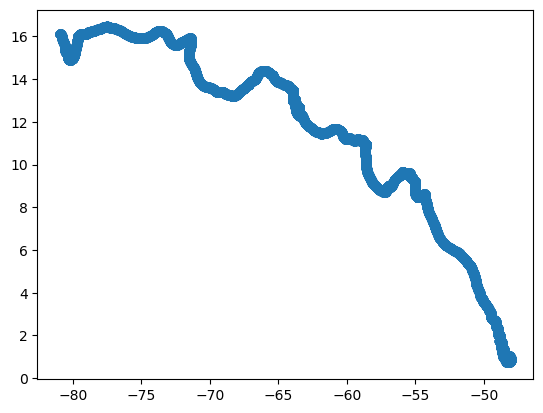

In [3]:
import matplotlib.pyplot as plt

plt.scatter(df['Longitude'],df['Latitude'])

In [4]:
datasets = []

for file in sorted(Path("/work/bk1450/b383184/Amazon/Mercator/data/Tara_Microbiomes_Drift/datasets").glob("*.tab")):

    # Find header
    with open(file) as f:
        for i, line in enumerate(f):
            if line.startswith("Latitude"):
                header_line = i
                break

    df = pd.read_csv(
        file,
        sep="\t",
        skiprows=header_line,
        parse_dates=["Date/Time"]
    )

    df = (df.rename(columns={"Date/Time": "time", "Latitude": "lat",
                             "Longitude": "lon", "Depth water [m]": "depth"})
            .sort_values("time")
            .drop_duplicates(subset="time")
            .reset_index(drop=True))

    drifter_id = int(df["ID"].iat[0])

    # Index by observation number, NOT by time: the drifters are a ragged
    # collection with their own (partly repeated) timestamps, so making time
    # the index forces xr.concat to align 43 disjoint time axes.
    ds = xr.Dataset(
        {v: ("obs", df[v].values) for v in ("lat", "lon", "depth", "time")},
        coords={"obs": np.arange(len(df))},
    ).expand_dims(drifter=[drifter_id])

    datasets.append(ds)

combined = xr.concat(datasets, dim="drifter", join="outer")
combined

<xarray.Dataset> Size: 63MB
Dimensions:  (drifter: 43, obs: 45280)
Coordinates:
  * obs      (obs) int64 362kB 0 1 2 3 4 5 ... 45275 45276 45277 45278 45279
  * drifter  (drifter) int64 344B 30 31 32 33 34 35 36 ... 67 68 69 71 72 73 74
Data variables:
    lat      (drifter, obs) float64 16MB 1.06 1.052 1.052 1.051 ... nan nan nan
    lon      (drifter, obs) float64 16MB -48.07 -48.07 -48.07 ... nan nan nan
    depth    (drifter, obs) float64 16MB 0.0 0.0 0.0 0.0 0.0 ... nan nan nan nan
    time     (drifter, obs) datetime64[ns] 16MB 2021-09-16T01:08:47 ... NaT

## Per-drifter dataframes and derived properties

The `.tab` files carry **only** `Latitude`, `Longitude`, `Depth water [m]`, `ID` and
`Date/Time`. These are GPS-only surface drifters, so there is **no salinity and no
temperature**, and `Depth` is identically 0 at every point (they follow the upper ~50 cm).

The only fields we can colour a scatter by are therefore *time since deployment*, the
*depth* flag itself, and a *drift speed* derived from successive GPS fixes.

In [5]:
def read_tab(file):
    """Read one PANGAEA .tab drifter file into a tidy dataframe."""
    with open(file) as f:
        for i, line in enumerate(f):
            if line.startswith("Latitude"):
                header_line = i
                break

    df = pd.read_csv(file, sep="\t", skiprows=header_line, parse_dates=["Date/Time"])
    df = (df.rename(columns={"Date/Time": "time", "Latitude": "lat",
                             "Longitude": "lon", "Depth water [m]": "depth"})
            .sort_values("time")
            .drop_duplicates(subset="time")      # <- the duplicate timestamps that broke concat
            .reset_index(drop=True))
    df["drifter"] = int(df["ID"].iat[0])

    # derived properties (great-circle-ish displacement / elapsed time)
    dt = np.diff(df["time"].values).astype("timedelta64[s]").astype(float)
    dx = np.diff(df["lon"].values) * 111e3 * np.cos(np.deg2rad(df["lat"].values[:-1]))
    dy = np.diff(df["lat"].values) * 111e3
    speed = np.r_[np.nan, np.hypot(dx, dy) / np.where(dt > 0, dt, np.nan)]

    df["speed"] = np.clip(speed, 0, 3)           # clip a few GPS-jump outliers
    df["days"]  = (df["time"] - df["time"].iat[0]).dt.total_seconds() / 86400
    return df


dfs = [read_tab(f) for f in sorted(DATA.glob("*.tab"))]
print(f"{len(dfs)} drifters loaded")
print("unique depth values in the whole dataset:",
      np.unique(np.concatenate([d["depth"].values for d in dfs])))
dfs[0].head()

43 drifters loaded
unique depth values in the whole dataset: [0]


,lat,lon,depth,ID,time,drifter,speed,days
0,1.05984,-48.06906,0,30,2021-09-16 01:08:47,30,NaN,0.000000
1,1.05203,-48.06753,0,30,2021-09-16 01:13:48,30,2.934827,0.003484
2,1.05182,-48.06641,0,30,2021-09-16 01:18:47,30,0.422963,0.006944
3,1.05144,-48.06531,0,30,2021-09-16 01:23:46,30,0.431976,0.010405
4,1.05093,-48.06421,0,30,2021-09-16 01:28:43,30,0.453085,0.013843


## Which drifters start at the mouth of the Amazon plume?

Select on the release position. The box below covers the delta and the inner plume;
it is deliberately the only place the selection is defined, so it is easy to tighten.

In [6]:
# Amazon river mouth / inner plume box
MOUTH = dict(lon=(-51.5, -47.5), lat=(-0.5, 2.5))

def in_mouth(df):
    return (MOUTH["lon"][0] <= df["lon"].iat[0] <= MOUTH["lon"][1] and
            MOUTH["lat"][0] <= df["lat"].iat[0] <= MOUTH["lat"][1])

mouth_dfs = [d for d in dfs if in_mouth(d)]
other_dfs = [d for d in dfs if not in_mouth(d)]
mouth_ids = sorted(int(d["drifter"].iat[0]) for d in mouth_dfs)

print(f"{len(mouth_ids)} of {len(dfs)} drifters start at the Amazon mouth: {mouth_ids}")

summary = pd.DataFrame([
    dict(drifter=int(d["drifter"].iat[0]),
         lon0=round(d["lon"].iat[0], 4), lat0=round(d["lat"].iat[0], 4),
         start=d["time"].iat[0], n_obs=len(d),
         duration_d=round(d["days"].iat[-1], 1),
         mean_speed=round(np.nanmean(d["speed"]), 3))
    for d in mouth_dfs
]).sort_values("lat0")
summary

6 of 43 drifters start at the Amazon mouth: [30, 42, 50, 52, 68, 73]


,drifter,lon0,lat0,start,n_obs,duration_d,mean_speed
1,42,-50.4888,0.3994,2021-09-07 17:04:56,533,32.3,0.976
3,52,-50.4883,0.4004,2021-09-07 14:04:44,13297,121.7,0.490
2,50,-50.4884,0.4006,2021-09-07 09:51:28,27036,155.9,0.114
0,30,-48.0691,1.0598,2021-09-16 01:08:47,35004,128.7,0.496
4,68,-48.0951,1.0964,2021-09-15 20:04:43,4837,16.9,0.764
5,73,-48.0643,1.1096,2021-09-15 12:02:39,13934,78.0,0.590


## Trajectories

In [7]:
def basemap(ax, extent):
    ax.set_extent(extent, crs=PC)
    ax.add_feature(cfeature.LAND,  fc="#e8e4dc", zorder=0)
    ax.add_feature(cfeature.OCEAN, fc="#f4f8fb", zorder=0)
    ax.add_feature(cfeature.COASTLINE, lw=0.5, ec="#7a8288")
    ax.add_feature(cfeature.RIVERS,    lw=0.6, ec="#8fb8d6")
    g = ax.gridlines(draw_labels=True, lw=0.3, color="#c9d1d9", alpha=0.7)
    g.top_labels = g.right_labels = False
    return ax

def mouth_box(ax):
    ax.add_patch(plt.Rectangle(
        (MOUTH["lon"][0], MOUTH["lat"][0]), np.ptp(MOUTH["lon"]), np.ptp(MOUTH["lat"]),
        fc="none", ec="#d1495b", lw=1.6, ls="--", transform=PC, zorder=5))

colors = plt.cm.tab10(np.linspace(0.05, 0.9, len(mouth_dfs)))

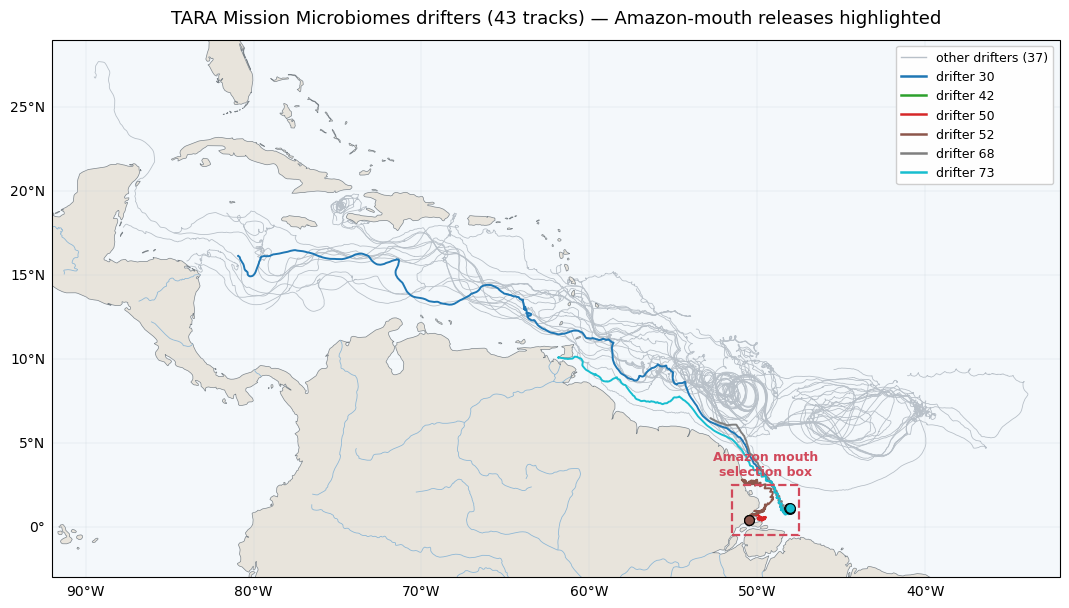

In [8]:
fig = plt.figure(figsize=(13, 8))
ax = basemap(plt.axes(projection=PC), [-92, -32, -3, 29])

for d in other_dfs:
    ax.plot(d["lon"], d["lat"], lw=0.6, color="#b8c0c8", transform=PC, zorder=1)

for d, c in zip(mouth_dfs, colors):
    ax.plot(d["lon"], d["lat"], lw=1.4, color=c, transform=PC, zorder=3)
    ax.plot(d["lon"].iat[0], d["lat"].iat[0], "o", ms=7, mfc=c, mec="k", mew=0.8,
            transform=PC, zorder=4)

mouth_box(ax)
ax.text(-49.5, 2.9, "Amazon mouth\nselection box", color="#d1495b", fontsize=9,
        ha="center", va="bottom", fontweight="bold", transform=PC)

ax.legend(handles=[Line2D([], [], color="#b8c0c8", lw=1,
                          label=f"other drifters ({len(other_dfs)})")] +
                  [Line2D([], [], color=c, lw=1.8,
                          label=f"drifter {int(d['drifter'].iat[0])}")
                   for d, c in zip(mouth_dfs, colors)],
          loc="upper right", fontsize=9, framealpha=0.95)

ax.set_title("TARA Mission Microbiomes drifters (43 tracks) — Amazon-mouth releases highlighted",
             fontsize=13, pad=12)
fig.savefig(OUT / "fig1_all_trajectories.png", dpi=150, bbox_inches="tight")

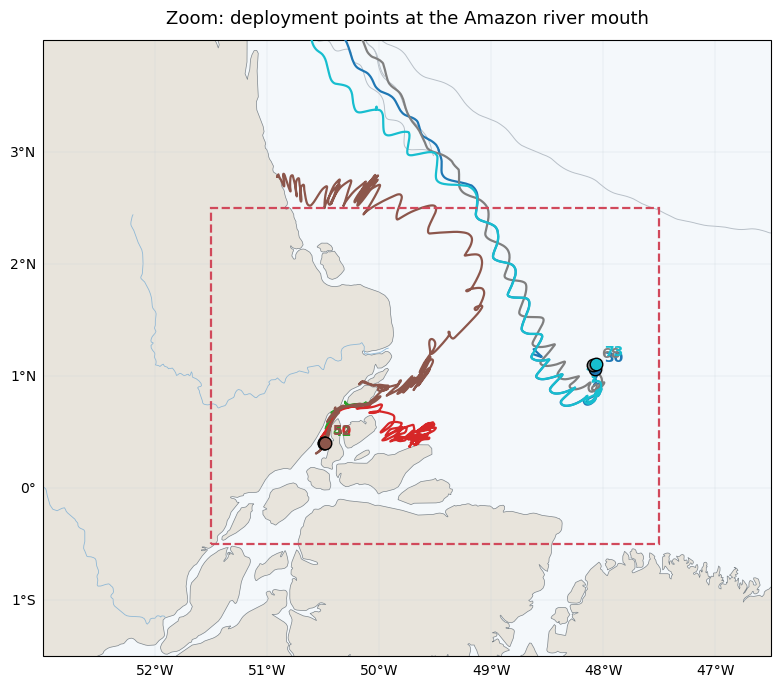

In [9]:
fig = plt.figure(figsize=(11, 8))
ax = basemap(plt.axes(projection=PC), [-53, -46.5, -1.5, 4])

for d in other_dfs:
    ax.plot(d["lon"], d["lat"], lw=0.7, color="#b8c0c8", transform=PC, zorder=1)

for d, c in zip(mouth_dfs, colors):
    did = int(d["drifter"].iat[0])
    ax.plot(d["lon"], d["lat"], lw=1.6, color=c, transform=PC, zorder=3)
    ax.plot(d["lon"].iat[0], d["lat"].iat[0], "o", ms=9, mfc=c, mec="k", mew=1,
            transform=PC, zorder=4)
    ax.annotate(str(did), (d["lon"].iat[0], d["lat"].iat[0]), xytext=(6, 6),
                textcoords="offset points", fontsize=10, fontweight="bold",
                color=c, zorder=5)

mouth_box(ax)
ax.set_title("Zoom: deployment points at the Amazon river mouth", fontsize=13, pad=12)
fig.savefig(OUT / "fig2_mouth_zoom.png", dpi=150, bbox_inches="tight")

## Scatter of the Amazon-mouth drifters, coloured by the properties they carry

Reminder: there is **no salinity or temperature** in this dataset, and `depth` is a
constant 0 — the third panel is shown only to make that explicit. To colour these
tracks by salinity you would have to co-locate them against a model/satellite field
(e.g. the Mercator output in the parent directory, or SMOS/SMAP).

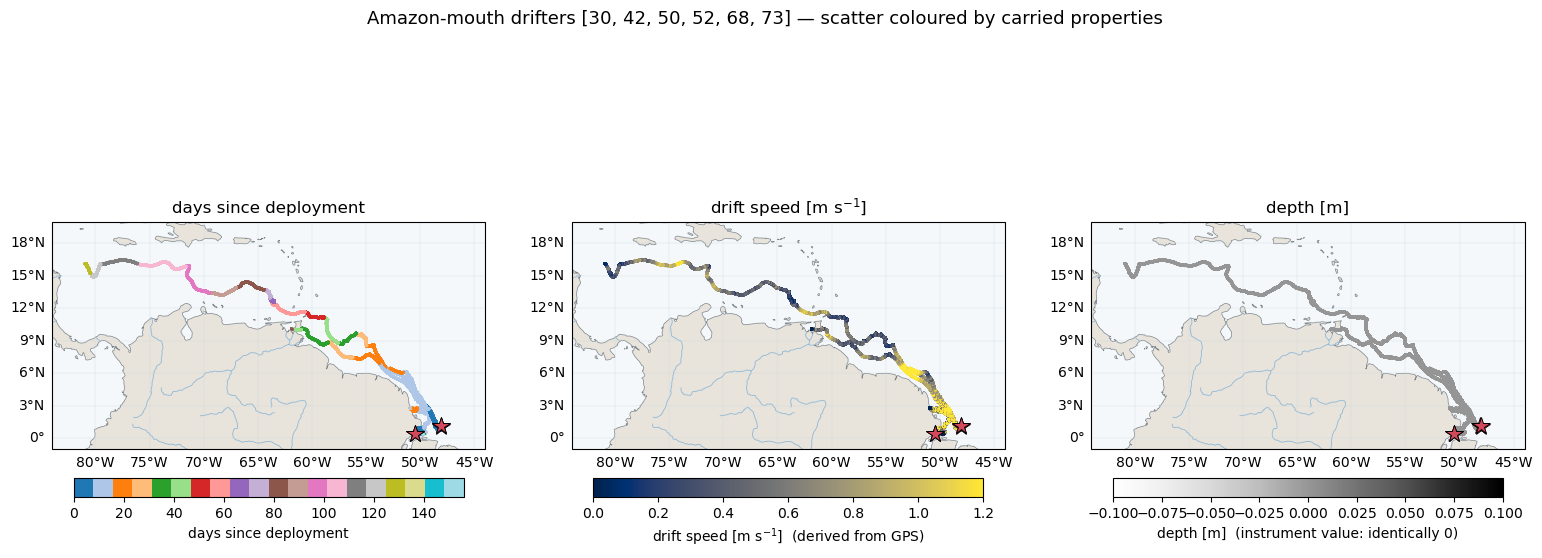

In [10]:
props = [
    ("days",  "days since deployment",                          "tab20", None),
    ("speed", "drift speed [m s$^{-1}$]  (derived from GPS)",   "cividis", (0, 1.2)),
    ("depth", "depth [m]  (instrument value: identically 0)",   "Greys",  (0, 0)),
]

allm = pd.concat(mouth_dfs)

fig, axs = plt.subplots(1, 3, figsize=(19, 6.2), subplot_kw=dict(projection=PC))
for ax, (key, label, cmap, vlim) in zip(axs, props):
    basemap(ax, [-84, -44, -1, 20])
    vmin, vmax = vlim if vlim else (allm[key].min(), allm[key].max())
    s = ax.scatter(allm["lon"], allm["lat"], c=allm[key], s=1.5, cmap=cmap,
                   vmin=vmin, vmax=vmax, transform=PC, zorder=3)
    for d in mouth_dfs:
        ax.plot(d["lon"].iat[0], d["lat"].iat[0], "*", ms=13, mfc="#d1495b",
                mec="k", mew=0.6, transform=PC, zorder=4)
    cb = fig.colorbar(s, ax=ax, orientation="horizontal", pad=0.06, shrink=0.9)
    cb.set_label(label, fontsize=10)
    ax.set_title(label.split("  (")[0], fontsize=12)

fig.suptitle(f"Amazon-mouth drifters {mouth_ids} — scatter coloured by carried properties",
             fontsize=13, y=0.98)
fig.savefig(OUT / "fig3_mouth_scatter_properties.png", dpi=150, bbox_inches="tight")

## Save the combined dataset for the virtual-particle comparison

In [11]:
combined.to_netcdf(OUT / "tara_drifters.nc")

# release positions / times of the mouth drifters, ready to seed virtual particles
release = summary[["drifter", "lon0", "lat0", "start"]].reset_index(drop=True)
release.to_csv(OUT / "amazon_mouth_release.csv", index=False)
release

,drifter,lon0,lat0,start
0,42,-50.4888,0.3994,2021-09-07 17:04:56
1,52,-50.4883,0.4004,2021-09-07 14:04:44
2,50,-50.4884,0.4006,2021-09-07 09:51:28
3,30,-48.0691,1.0598,2021-09-16 01:08:47
4,68,-48.0951,1.0964,2021-09-15 20:04:43
5,73,-48.0643,1.1096,2021-09-15 12:02:39
